# Explainable Commodity Prices — Results Orchestrator

**Audience:** senior economics staff reviewing the full analysis.

This notebook surfaces the headline results from the full pipeline (vanilla AE baseline + β-VAE robustness). Implementation detail lives in `reports/` and the `src/eqcp` pipelines.

### Pipeline map
| Stage | Command | Output |
|-------|---------|--------|
| Overall macro spanning | `make mapping` / `make mapping-beta` | `results/macro_mapping[_beta]/` |
| Sector decomposition | `make sectors` / `make sectors-beta` | `results/sector_analysis[_beta]/` |
| Forecast attribution | `make forecast` / `make forecast-beta` | `results/forecast_pbsv[_beta]/` |

**Panel:** 21 daily commodity futures. **Macro:** 37 stationary variables. **Factors:** K=5. **Seed:** 0.



## 0. Setup & run pipelines


In [9]:
from __future__ import annotations

import subprocess
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})
SPANNED_C, WEAK_C, NEUTRAL_C = "#2A6F97", "#C44E52", "#8C8C8C"
SECTOR_C = {"agriculture": "#55A868", "energy": "#DD8452", "metals": "#8172B3"}

# Resolve project root and make `eqcp` importable without a separate pip install.
ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = Path(__file__).resolve().parent if "__file__" in dir() else ROOT
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError(
        "Open/run this notebook with the working directory set to the project root "
        "(explainable_commodity_prices/)."
    )
_SRC = ROOT / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

from eqcp.config import load_factor_model_config

factor_cfg = load_factor_model_config()
print(f"Project root: {ROOT}")
print(f"Factor model: K={factor_cfg.n_factors}, vanilla activation={factor_cfg.activation}, beta={factor_cfg.beta}")

def run(cmd: str) -> None:
    print(f"\n>>> {cmd}")
    subprocess.run(cmd, shell=True, check=True, cwd=ROOT)

# Uncomment to regenerate all artifacts (slow: ~15-30 min total)
# run("make mapping && make mapping-beta && make sectors && make sectors-beta && make forecast && make forecast-beta")




Project root: /Users/shreyanshsharma/Desktop/Resume Projects/Summer Project/explainable_commodity_prices
Factor model: K=5, vanilla activation=relu, beta=4.0


## 1. Dimension analysis — overall macro spanning

**Question:** Of the K=5 latent commodity factors, how many directions are *genuinely* spanned by the macro panel out-of-sample?

**Verdict rule:** OOS canonical correlation ρ > 0.3 **and** circular-shift permutation p < 0.05.


2 of 5 factor directions are macro-spanned out-of-sample.



,rho_insample,rho_oos,perm_p,spanned
dim,,,,
dim1,0.696,0.642,0.001,True
dim2,0.554,0.487,0.001,True
dim3,0.295,0.197,0.001,False
dim4,0.204,0.130,0.001,False
dim5,0.123,-0.000,0.538,False


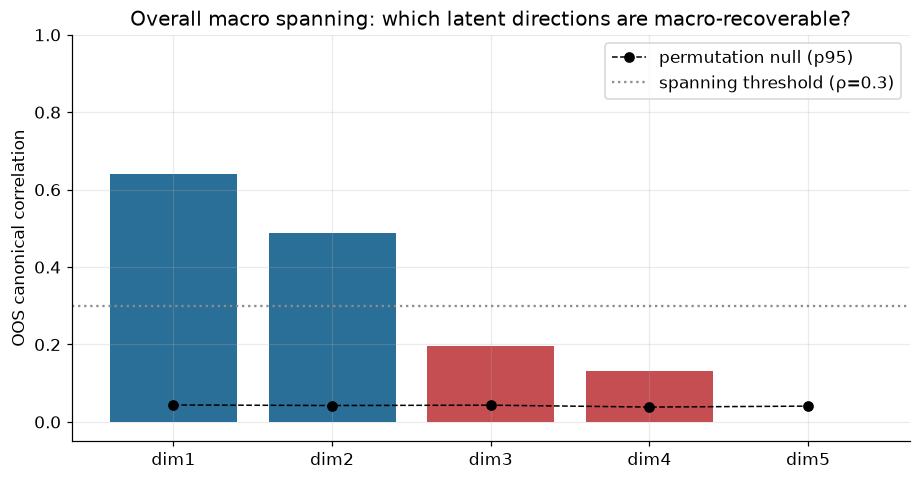

dim1: top macro drivers → xle(+0.85), be_5y(+0.66), inflsw_5y(+0.66), fx_usdcad(-0.59), fx_usdnok(-0.57)
dim2: top macro drivers → fx_audusd(+0.66), fx_bbdxy(-0.64), fx_dxy(-0.63), fx_usdclp(-0.57), fx_usdcnh(-0.55)


In [10]:
cc = pd.read_csv(ROOT / "results/macro_mapping/canonical_correlations.csv", index_col=0)
cc["spanned"] = (cc["rho_oos"] > 0.3) & (cc["perm_p"] < 0.05)
n_spanned = int(cc["spanned"].sum())
print(f"{n_spanned} of {len(cc)} factor directions are macro-spanned out-of-sample.\n")
display(cc[["rho_insample", "rho_oos", "perm_p", "spanned"]].round(3))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
colors = [SPANNED_C if s else WEAK_C for s in cc["spanned"]]
ax.bar(cc.index, cc["rho_oos"], color=colors)
ax.plot(cc.index, cc["null_p95"], "k--o", lw=1, label="permutation null (p95)")
ax.axhline(0.3, color=NEUTRAL_C, ls=":", label="spanning threshold (ρ=0.3)")
ax.set_ylim(-0.05, 1.0)
ax.set_ylabel("OOS canonical correlation")
ax.set_title("Overall macro spanning: which latent directions are macro-recoverable?")
ax.legend()
plt.tight_layout(); plt.show()

loadings = pd.read_csv(ROOT / "results/macro_mapping/canonical_loadings_macro.csv", index_col=0)
for dim in cc.index[cc["spanned"]]:
    top = loadings[dim].abs().sort_values(ascending=False).head(5)
    drivers = ", ".join(f"{v}({loadings.loc[v, dim]:+.2f})" for v in top.index)
    print(f"{dim}: top macro drivers → {drivers}")



## 2. Sector-wise mapping (vanilla vs β-VAE)

**Question:** Is the macro-spanning story uniform across sectors — and is it stable under β-VAE?

We expect **energy** to be the most macro-linked and **agriculture** the most idiosyncratic; the β-VAE run checks that ranking is not an AE artefact.



Vanilla AE — sector spanning summary


,block,n_commodities,n_factors,dim,rho_insample,rho_oos,perm_p_oos,spanned,top_macro,top_bloc,ridge,n_spanned_block
0,overall,21,5,dim1,0.696,0.642,0.002,True,xle(+0.85); be_5y(+0.66); inflsw_5y(+0.66); fx...,fx(+0.78); equity(-0.78); infl(-0.64),0.0,2
1,overall,21,5,dim2,0.554,0.487,0.002,True,fx_audusd(+0.66); fx_bbdxy(-0.64); fx_dxy(-0.6...,infl(+0.61); rates(+0.57); fx(+0.52),0.0,2
2,overall,21,5,dim3,0.295,0.197,0.002,False,tips_5y(+0.55); ust_5y(+0.54); ust_10y(+0.53);...,china(-0.67); rates(-0.56); credit(+0.30),0.0,2
3,overall,21,5,dim4,0.204,0.130,0.002,False,fx_usdbrl(+0.72); ust_2y(-0.23); tips_10y(-0.2...,credit(-0.51); rates(-0.41); vol(-0.32),0.0,2
4,overall,21,5,dim5,0.123,-0.000,0.539,False,ig_oas(-0.43); epu(-0.39); bdiy(+0.31); ovx(-0...,china(+0.45); uncert(+0.40); freight(-0.39),0.0,2
5,agriculture,9,3,dim1,0.415,0.358,0.002,True,fx_usdbrl(-0.70); fx_usdcad(-0.65); xle(+0.64)...,fx(-0.78); equity(+0.77); infl(+0.62),0.0,1
6,agriculture,9,3,dim2,0.179,0.046,0.036,False,move(-0.57); mxwo(+0.56); spx(+0.47); vix(-0.41),vol(-0.72); equity(+0.46); credit(-0.41),0.0,1
7,agriculture,9,3,dim3,0.140,0.055,0.022,False,xle(-0.35); fx_usdclp(-0.29); epu(-0.28); infl...,infl(-0.43); uncert(-0.42); fx(-0.41),0.0,1
8,energy,5,3,dim1,0.690,0.645,0.002,True,xle(+0.84); be_5y(+0.67); inflsw_5y(+0.67); in...,infl(+0.90); equity(+0.76); credit(-0.54),0.0,1
9,energy,5,3,dim2,0.230,0.067,0.006,False,ovx(-0.63); ig_oas(-0.51); hy_oas(-0.39); mxwo...,credit(+0.71); vol(+0.54); equity(-0.24),0.0,1



β-VAE — sector spanning summary


,block,n_commodities,n_factors,dim,rho_insample,rho_oos,perm_p_oos,spanned,top_macro,top_bloc,ridge,n_spanned_block
0,overall,21,5,dim1,0.687,0.634,0.002,True,xle(+0.85); be_5y(+0.67); inflsw_5y(+0.66); fx...,equity(+0.79); fx(-0.75); infl(+0.69),0.0,2
1,overall,21,5,dim2,0.513,0.443,0.002,True,fx_bbdxy(+0.69); fx_dxy(+0.68); fx_audusd(-0.6...,rates(+0.63); fx(+0.57); infl(+0.55),0.0,2
2,overall,21,5,dim3,0.260,0.038,0.068,False,epu(+0.49); ig_oas(+0.49); hy_oas(+0.37); gpr(...,uncert(+0.76); credit(+0.46); vol(+0.33),0.0,2
3,overall,21,5,dim4,0.163,0.001,0.437,False,mxef(-0.37); hscei(-0.31); gvz(+0.30); csi300(...,china(+0.79); freight(+0.26); fx(+0.19),0.0,2
4,overall,21,5,dim5,0.135,0.062,0.004,False,fx_usdbrl(-0.52); hscei(-0.28); move(+0.23); g...,equity(+0.42); freight(+0.42); credit(-0.39),0.0,2
5,agriculture,9,3,dim1,0.385,0.329,0.002,True,fx_usdbrl(-0.72); fx_usdcad(-0.63); xle(+0.61)...,fx(-0.80); equity(+0.70); infl(+0.63),0.0,1
6,agriculture,9,3,dim2,0.170,0.057,0.014,False,xle(+0.53); spx(+0.53); mxwo(+0.51); hy_oas(-0...,equity(+0.58); credit(-0.52); vol(-0.46),0.0,1
7,agriculture,9,3,dim3,0.147,0.052,0.022,False,ig_oas(-0.43); xle(+0.38); fx_usdcnh(-0.34); f...,credit(-0.59); freight(+0.53); equity(+0.25),0.0,1
8,energy,5,3,dim1,0.547,0.422,0.002,True,xle(+0.87); inflsw_5y(+0.64); be_5y(+0.63); in...,equity(+0.83); infl(+0.78); credit(-0.72),0.0,1
9,energy,5,3,dim2,0.247,0.047,0.026,False,hy_oas(-0.48); ig_oas(-0.47); ovx(-0.43); mxwo...,uncert(+0.88); vol(+0.30); rates(-0.15),0.0,1



Spanned-direction counts by block (vanilla vs β-VAE):


,block,n_spanned_vanilla,n_spanned_beta,match
0,agriculture,1,1,True
1,energy,1,1,True
2,metals,1,1,True
3,overall,2,2,True


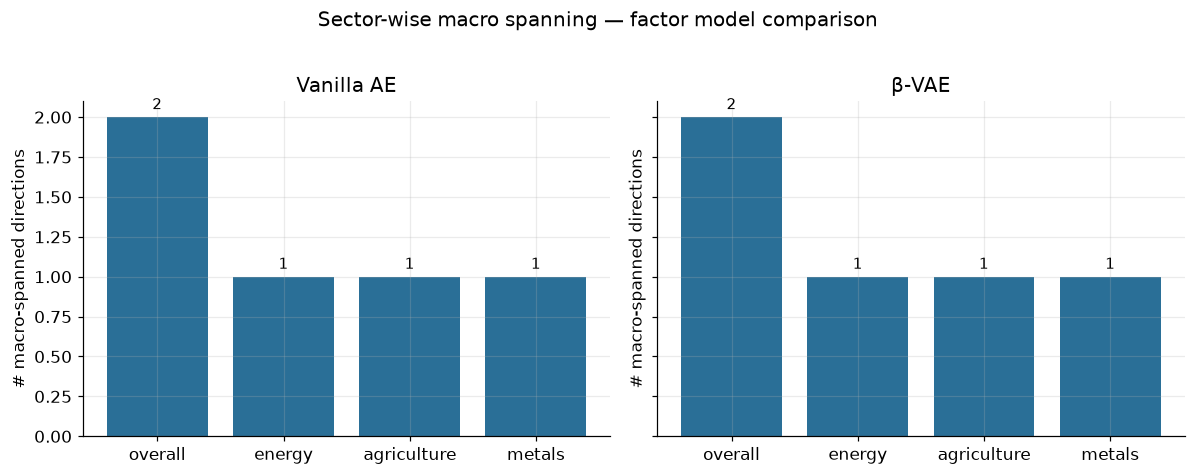


Vanilla sector spanning bars:


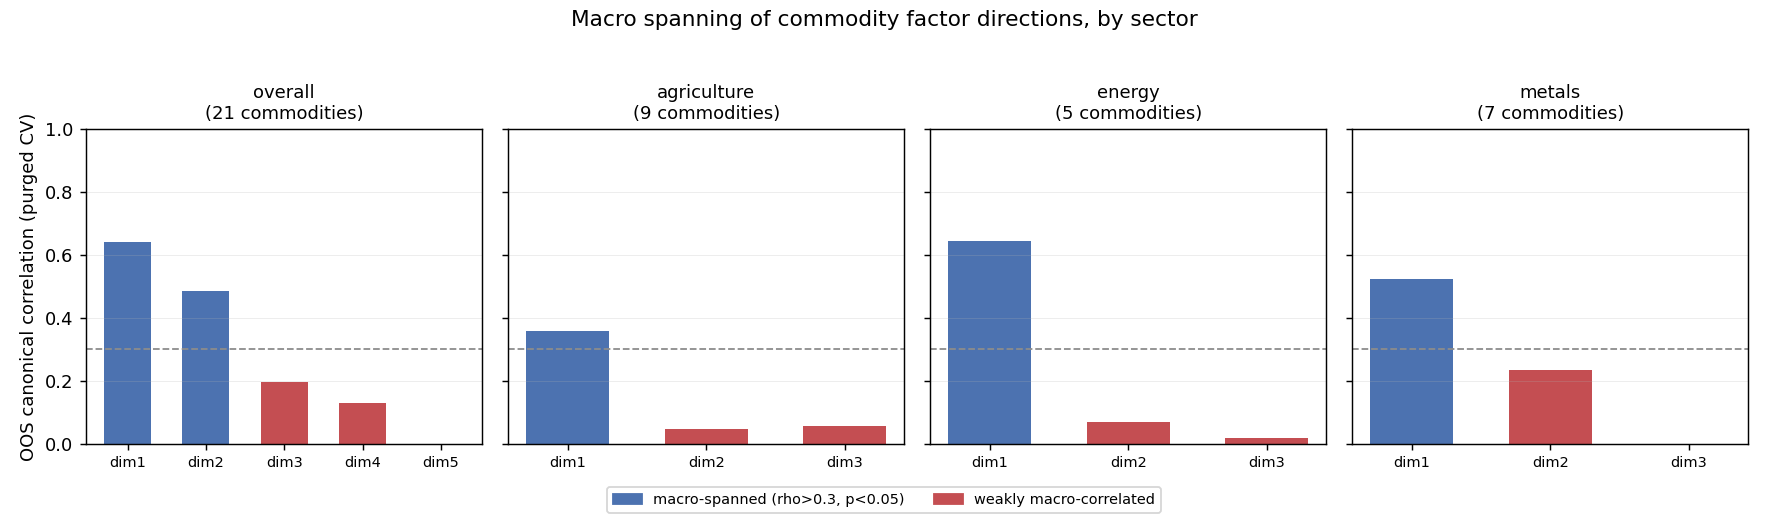


β-VAE sector spanning bars:


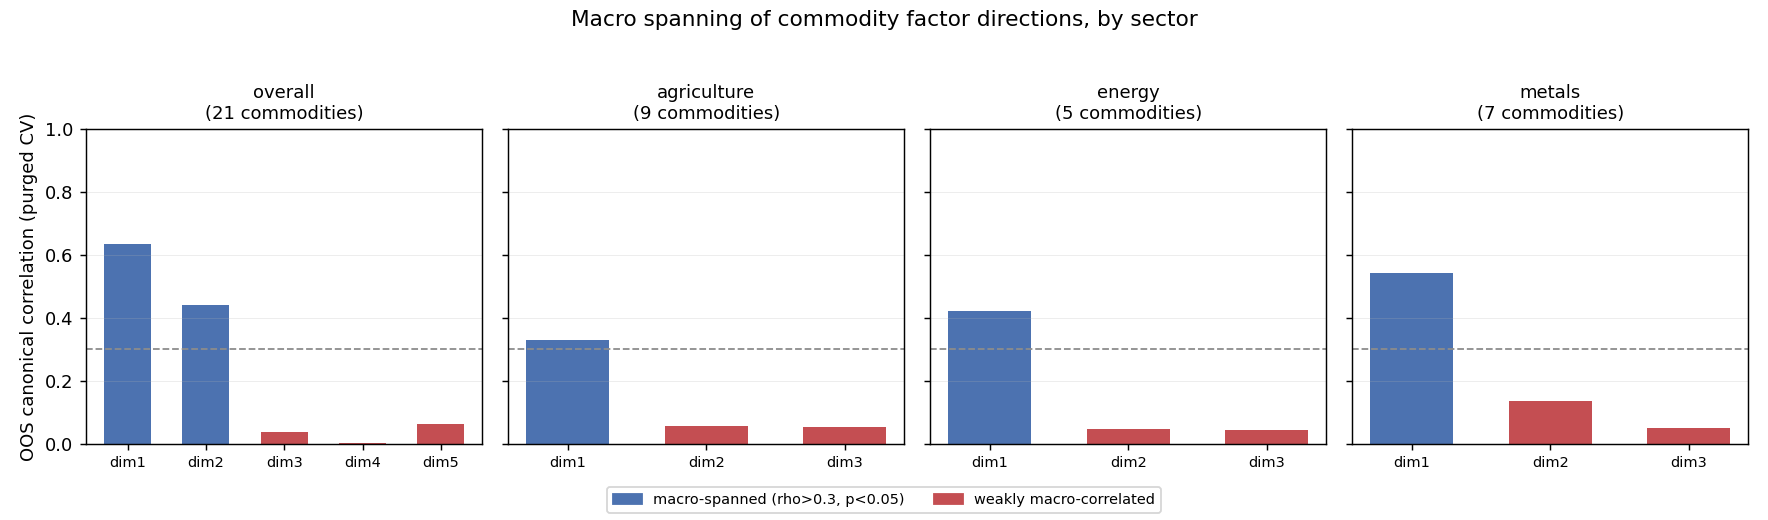

In [11]:
def _sector_spanned_counts(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    return df.groupby("block")["spanned"].sum().astype(int)

vanilla_path = ROOT / "results/sector_analysis/sector_cca_summary.csv"
beta_path = ROOT / "results/sector_analysis_beta/sector_cca_summary.csv"

sector_v = pd.read_csv(vanilla_path)
print("Vanilla AE — sector spanning summary")
display(sector_v.round(3))

if beta_path.exists():
    sector_b = pd.read_csv(beta_path)
    print("\nβ-VAE — sector spanning summary")
    display(sector_b.round(3))

    cmp = pd.DataFrame({
        "block": _sector_spanned_counts(vanilla_path).index,
        "n_spanned_vanilla": _sector_spanned_counts(vanilla_path).to_numpy(),
        "n_spanned_beta": _sector_spanned_counts(beta_path).reindex(
            _sector_spanned_counts(vanilla_path).index
        ).fillna(0).astype(int).to_numpy(),
    })
    cmp["match"] = cmp["n_spanned_vanilla"] == cmp["n_spanned_beta"]
    print("\nSpanned-direction counts by block (vanilla vs β-VAE):")
    display(cmp)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
    for ax, df, title in zip(axes, [sector_v, sector_b], ["Vanilla AE", "β-VAE"]):
        counts = df.groupby("block")["spanned"].sum().reindex(
            ["overall", "energy", "agriculture", "metals"]
        ).fillna(0)
        ax.bar(counts.index, counts.to_numpy(), color=SPANNED_C)
        for i, v in enumerate(counts.to_numpy()):
            ax.text(i, v + 0.05, str(int(v)), ha="center", fontsize=10)
        ax.set_ylabel("# macro-spanned directions")
        ax.set_title(title)
    fig.suptitle("Sector-wise macro spanning — factor model comparison", y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("Run `make sectors-beta` for β-VAE sector results.")

for label, subdir in [("Vanilla", "sector_analysis"), ("β-VAE", "sector_analysis_beta")]:
    fig = ROOT / "figures" / subdir / "sector_spanning_bars.png"
    if fig.exists():
        print(f"\n{label} sector spanning bars:")
        display(Image(filename=str(fig)))



## 3. Factor model comparison — Vanilla AE vs β-VAE

**Question:** Does the β-VAE (KL-regularised, disentanglement-prior latents) change how many directions are macro-spanned?

β=4.0 penalises redundant latents; we compare OOS spanning counts side-by-side.


,model,beta,n_spanned,rho_oos_min,rho_oos_mean,perm_p_min,perm_p_mean,ridge
0,vanilla,NaN,2,-0.0003,0.2912,0.0360,0.001,0.0
1,beta_vae,4.0,2,-0.0359,0.2357,0.6194,0.001,0.0


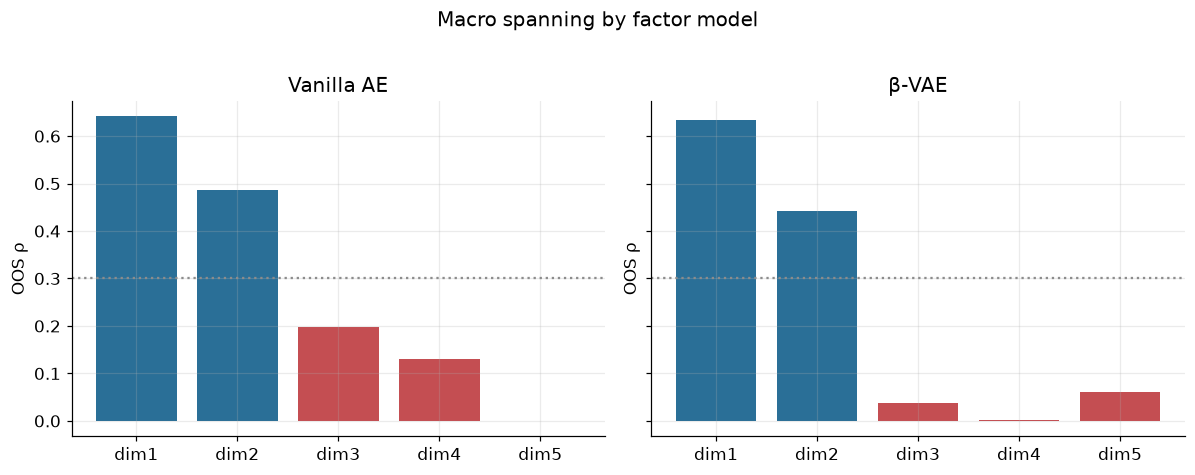

In [12]:
cmp_path = ROOT / "results/macro_mapping/factor_model_comparison.csv"
if cmp_path.exists():
    cmp_df = pd.read_csv(cmp_path)
    display(cmp_df.round(4))
else:
    print("Run `make mapping` first to generate factor_model_comparison.csv")

vanilla_cc = pd.read_csv(ROOT / "results/macro_mapping/canonical_correlations.csv", index_col=0)
beta_cc_path = ROOT / "results/macro_mapping_beta/canonical_correlations.csv"
if beta_cc_path.exists():
    beta_cc = pd.read_csv(beta_cc_path, index_col=0)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
    for ax, df, title in zip(
        axes,
        [vanilla_cc, beta_cc],
        ["Vanilla AE", "β-VAE"],
    ):
        sp = (df["rho_oos"] > 0.3) & (df["perm_p"] < 0.05)
        ax.bar(df.index, df["rho_oos"], color=[SPANNED_C if s else WEAK_C for s in sp])
        ax.axhline(0.3, color=NEUTRAL_C, ls=":")
        ax.set_title(title)
        ax.set_ylabel("OOS ρ")
    fig.suptitle("Macro spanning by factor model", y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("Run `make mapping-beta` to generate beta-VAE spanning results.")



## 4. Forecast attribution — PBSV (Shapley values)

**Question:** Does macro information add *out-of-sample forecast value* for commodity returns, and which canonical directions contribute?

PBSV attributes the AR(1)-vs-full MSE gain to each macro-linked canonical variate. Negative φ means the direction hurts the forecast.


,horizon,dim,spanned,phi_std,phi_pct_of_ar1_mse,boot_lo,boot_hi
0,1,cv1,True,-0.000000,-0.050799,-0.000001,0.000000
1,1,cv2,False,-0.000000,-0.119367,-0.000001,-0.000000
2,1,cv3,False,-0.000000,-0.042239,-0.000001,0.000001
3,1,cv4,False,0.000000,0.051252,-0.000000,0.000001
4,1,cv5,False,-0.000001,-0.148969,-0.000001,-0.000000


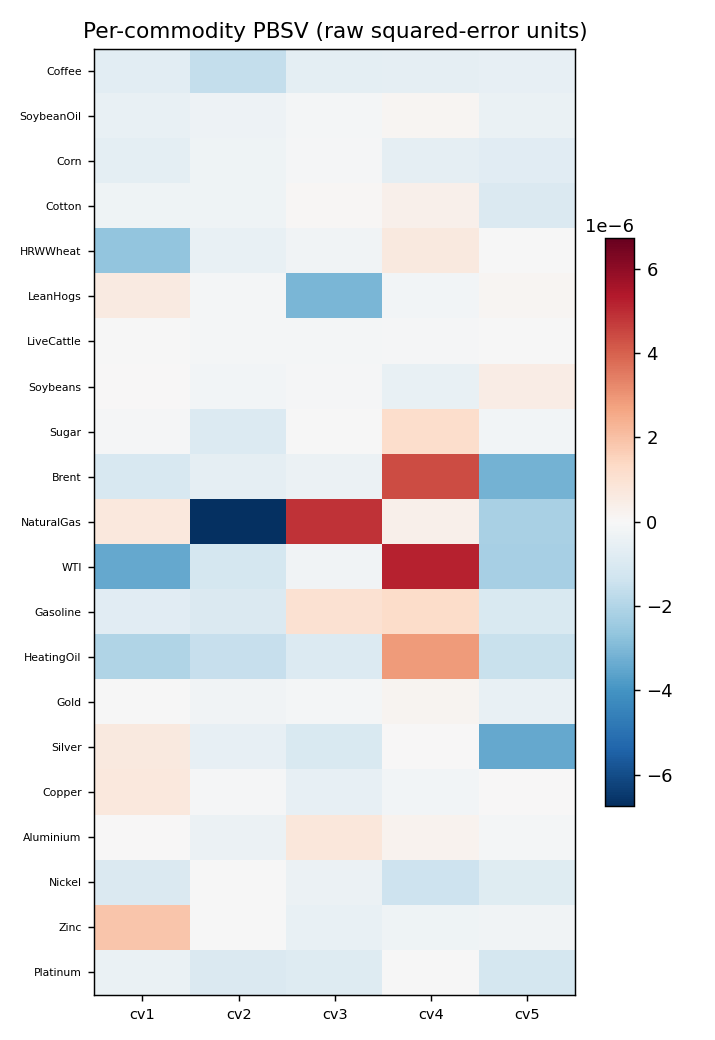

h=1 pooled R²_OOS(full vs AR1) = -0.00310  |  Clark-West p = 0.3280  |  gate_passed = False


In [13]:
shapley = pd.read_csv(ROOT / "results/forecast_pbsv/pbsv_shapley.csv")
h1 = shapley[shapley["horizon"] == 1].copy()
display(h1.round(6))

fig_path = ROOT / "figures/forecast_pbsv/pbsv_per_commodity.png"
if fig_path.exists():
    display(Image(filename=str(fig_path)))

pooled = pd.read_csv(ROOT / "results/forecast_pbsv/forecast_accuracy_pooled.csv")
headline = pooled[pooled["horizon"] == 1].iloc[0]
print(
    f"h=1 pooled R²_OOS(full vs AR1) = {headline['r2_pool_std_vs_ar1']:+.5f}  |  "
    f"Clark-West p = {headline['cw_pool_p']:.4f}  |  "
    f"gate_passed = {bool(headline['gate_passed'])}"
)



In [14]:
# β-VAE forecast comparison (optional — requires `make forecast-beta`)
beta_pooled_path = ROOT / "results/forecast_pbsv_beta/forecast_accuracy_pooled.csv"
if beta_pooled_path.exists():
    beta_pooled = pd.read_csv(beta_pooled_path)
    beta_h1 = beta_pooled[beta_pooled["horizon"] == 1].iloc[0]
    compare = pd.DataFrame(
        {
            "model": ["vanilla AE", "β-VAE"],
            "r2_oos_vs_ar1": [headline["r2_pool_std_vs_ar1"], beta_h1["r2_pool_std_vs_ar1"]],
            "cw_p": [headline["cw_pool_p"], beta_h1["cw_pool_p"]],
            "gate_passed": [bool(headline["gate_passed"]), bool(beta_h1["gate_passed"])],
        }
    )
    print("Forecast null is stable across factor models:")
    display(compare.round(5))
else:
    print("Run `make forecast-beta` for the β-VAE forecast comparison.")


Forecast null is stable across factor models:


,model,r2_oos_vs_ar1,cw_p,gate_passed
0,vanilla AE,-0.00310,0.32804,False
1,β-VAE,-0.00506,0.75458,False


## 5. Forecast horizon analysis

**Question:** Does macro transmission strengthen at longer horizons (weekly / monthly / quarterly)?

We report pooled OOS accuracy and grouped PBSV (spanned vs weak blocks) at h ∈ {1, 5, 21, 63} trading days.


,horizon,r2_oos_vs_ar1,cw_p_overlap,phi_spanned,phi_weak,retained_share_spanned,gate_passed
0,1,-0.00310,0.32804,-0.00000,-0.00000,0.89305,False
1,5,-0.00481,0.99649,-0.00000,-0.00001,1.07648,False
2,21,-0.00338,0.69025,-0.00001,-0.00002,1.53740,False
3,63,-0.00209,0.08790,-0.00001,-0.00003,0.88436,False


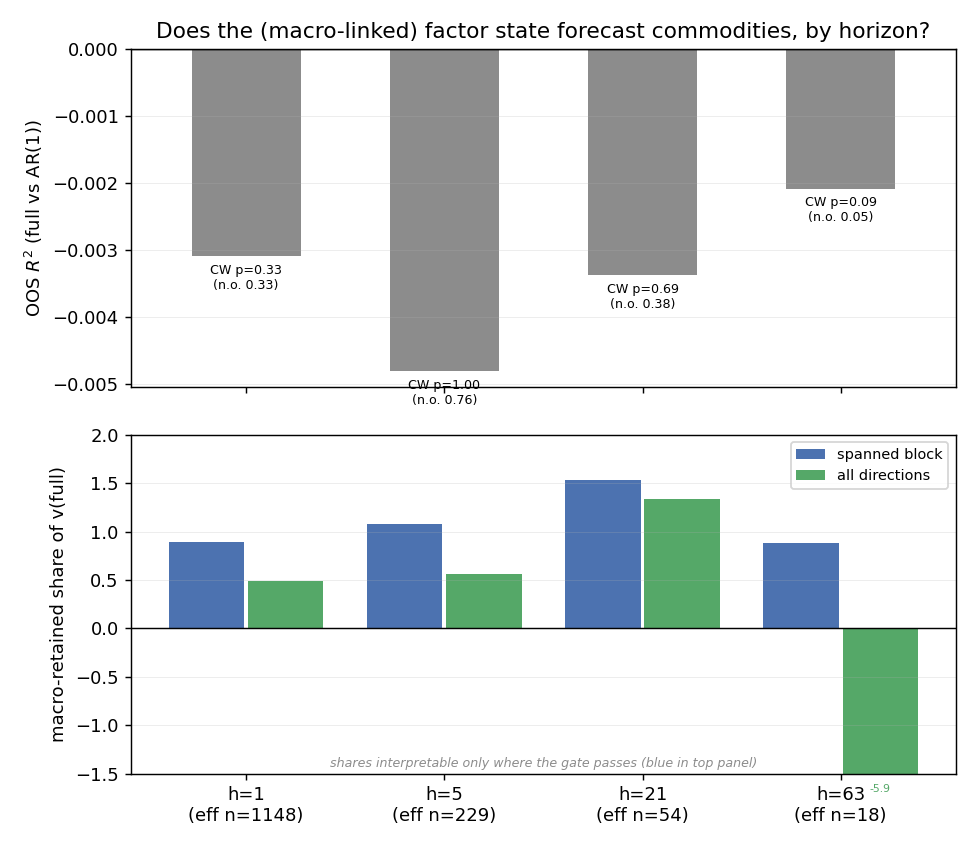


Grouped PBSV by horizon (spanned vs weak blocks):


,horizon,phi_spanned,phi_weak,boot_lo_spanned,boot_hi_spanned,boot_lo_weak,boot_hi_weak,v_spanned,v_weak,v_full,interaction
0,1,-0.000000,-0.000001,-0.000001,0.000000,-0.000002,0.000000,-0.000000,-0.000001,-0.000001,-0.000000
1,5,-0.000002,-0.000007,-0.000003,-0.000001,-0.000011,-0.000005,-0.000002,-0.000007,-0.000009,-0.000000
2,21,-0.000009,-0.000016,-0.000019,0.000001,-0.000030,-0.000005,-0.000009,-0.000016,-0.000024,0.000000
3,63,-0.000012,-0.000034,-0.000033,0.000016,-0.000081,0.000009,-0.000011,-0.000033,-0.000045,-0.000002


In [15]:
trans = pd.read_csv(ROOT / "results/forecast_pbsv/macro_transmission_by_horizon.csv")
cols = [
    "horizon", "r2_oos_vs_ar1", "cw_p_overlap", "phi_spanned", "phi_weak",
    "retained_share_spanned", "gate_passed",
]
display(trans[cols].round(5))

fig_path = ROOT / "figures/forecast_pbsv/transmission_by_horizon.png"
if fig_path.exists():
    display(Image(filename=str(fig_path)))

grouped = pd.read_csv(ROOT / "results/forecast_pbsv/pbsv_grouped.csv")
print("\nGrouped PBSV by horizon (spanned vs weak blocks):")
display(grouped.round(6))



## 6. Takeaways

1. **Compression works:** ~5 latent factors summarise 21 commodity return series; **~2 directions** are macro-spanned OOS (dollar/inflation/energy-equity and dollar/commodity-FX).
2. **Sector heterogeneity:** Energy is the most macro-linked sector; agriculture the most idiosyncratic — **stable under β-VAE** (see §2 comparison table).
3. **β-VAE robustness:** Overall spanning count matches vanilla (2/5); sector spanned counts should agree block-by-block if the macro story is real.
4. **Forecast null:** Macro-linked factors explain contemporaneous co-movement but do **not** pass the share-of-gain gate at any horizon — consistent with near-efficient daily futures.
5. **Horizon ladder:** Longer horizons do not rescue forecast value (§5); gate fails at h ∈ {1, 5, 21, 63} for both factor models.

**Full reports:** `reports/macro_mapping_report.md`, `reports/sector_analysis_report.md`, `reports/sector_analysis_beta_report.md`, `reports/forecast_pbsv_report.md`.

